In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import ThomasFermi

From notes Chris made in paper: 

The single-electron states are of the form
$\begin{equation}
\psi_{nkm}(r,\theta,\phi) = \frac1{r\sqrt{\sin\theta}}[F_{nk}(r)\Theta^{(F)}_{km}(\theta,\phi) + G_{nk}(r) \Theta^{(G)}_{km}(\theta,\phi)]
\end{equation}$

where the radial functions satisfy (with units put back in)

$\begin{equation}
\left( \begin{array}{cc}
m_ec^2+q_eV & \hbar c(\frac kr + \partial_r) \\
\hbar c(\frac kr - \partial_r) & -m_ec^2+q_eV
\end{array} \right)
\left(\begin{array}{c} F_{nk}(r) \\ G_{nk}(r) \end{array}\right)
=
h_{nk}\left(\begin{array}{c} F_{nk}(r) \\ G_{nk}(r) \end{array}\right).
\end{equation}$

reordered to be a bit clearer 
$\begin{eqnarray}
-\frac{m_e c^2 + q_e V -h_{nk}}{\hbar c}F_{nk}(r) -  (\frac{k}{r})G_{nk}(r) &=& \partial_r G_{nk}(r) \\
\frac{k}{r} F_{nk}(r) + \frac{-m_e c^2 +q_e V - h_{nk}}{\hbar c }G_{nk}(r) & =& \partial_r F_{nk}(r)
\end{eqnarray}$

In [2]:
r_bohr_H = 5.2946541e-11 # bohr radius in meters
r_bohr_Mg = r_bohr_H/80 
r_min = r_bohr_Mg/3
print(r_min)

2.2061058750000002e-13


In [3]:
a_from_paper = 6.468e-10 

#r_max = (3*vol_per_atom/(4*np.pi))**(1/3) 
r_max = a_from_paper 

In [4]:
r_array = np.logspace(-13,-9.2,100)
pot_Hg = np.zeros(len(r_array))
pot_Cd = np.zeros(len(r_array))
pot_Te = np.zeros(len(r_array))
for i in range(len(r_array)):
    pot_Hg[i] = ThomasFermi.Potential(80,r_array[i])
    pot_Cd[i] = ThomasFermi.Potential(52,r_array[i])
    pot_Te[i] = ThomasFermi.Potential(48,r_array[i])

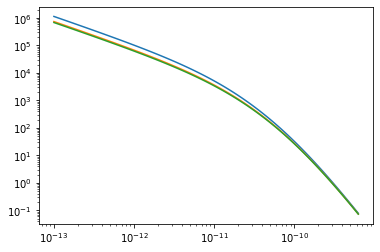

In [5]:
plt.loglog(r_array, pot_Hg)
plt.loglog(r_array, pot_Cd)
plt.loglog(r_array, pot_Te)
plt.show()

In [134]:
class ElectronWaveFunctionGRC:
    
    """
    
    Electron Wave Function class implements the parameters and RK-4 method for the electron's radial part of the 
    wave function.
    
    
    Parameters
    ----------
    
    nu: float
    
    k: float
       quantum number 
    
    h: float
       Energy eigenvalue 
    
    
    mu: float
        mass of the electron
    
    """

    def __init__(self, n, k, h, tol,Z):
        
        self.n = n
        self.k = k
        self.h = h
        self.mu = 9.1093837e-31 #kilograms #define in right units here
        self.c = 299792458. #m/s  #define in right units here
        self.hbar = 1.054571817e-34 #Js #define in right units here 
        self.charge = 1.60217663e-19 #Coulombs #define in the right units here 
        self.alpha = 0.0072973525643 #alpha 
        self.Z =  Z#define this 
        self.tol = tol

        
        self.nu = np.sqrt(self.k**2 - (self.alpha*self.Z)**2) 
        #print(self.nu,(self.alpha*self.Z)**2)
        self.coeff = None

    #This function returns the differential equation  
    #hoping the potential will work out ok here 
    def potential(self, r):
        #this is just the nucleus rn, will need to update with TF potential soon. 
        return ThomasFermi.Potential(self.Z,r)
    
    def diff_eq(self, r, F, G):
        
        dG = (self.h -self.mu*self.c**2 - self.charge*self.potential(r))* F/self.hbar/self.c  - (self.k/r)*G
            
        dF = (self.k/r) * F + (-self.h -self.mu*self.c**2 + self.charge*self.potential(r)) * G /self.hbar/self.c

        return np.asarray([dF, dG])
    
    
    def RK_4(self, r_min, r_inf, N):
        
        #this is in terms of r_star
        
        step_size = (r_inf - r_min) / (N-1)
        print(step_size)
        
        r_points = np.linspace(r_min, r_inf, N)        
        
        #print(r_points[0])
        
        
        #Define initial values for F and G
        #inner boundary condition
        F = np.sqrt(self.k**2 - self.nu**2)
        G = self.k - self.nu

        #print(F,G)
        #outer boundary condition is F = G
        
        #Arrays to keep track of r, F and G points:

        F_points = []
        G_points = []
        K_counts = []
        counter_K = 0
        K_check = 2.**50
        
        for r in r_points:  
            #Update F_points and G_points arrays:
            F_points.append(F)
            G_points.append(G)


            #Calculate all the slopes (each variable has a separate k-slope):
            (k1F, k1G) = tuple(step_size * self.diff_eq(r, F, G))

            (k2F, k2G) = tuple(step_size * self.diff_eq(r + 0.5*step_size, F + 0.5*k1F, G + 0.5*k1G))

            (k3F, k3G) = tuple(step_size * self.diff_eq(r + 0.5*step_size, F + 0.5*k2F, G + 0.5*k2G))

            (k4F, k4G) = tuple(step_size * self.diff_eq(r + step_size, F + k3F, G + k3G))


            #Calculate next F_point and G_point
            F = F + (k1F + 2*k2F + 2*k3F + k4F) / 6
            G = G + (k1G + 2*k2G + 2*k3G + k4G) / 6
            if F**2 + G**2 > K_check:
                print('true') 
                F = F/np.sqrt(K_check)
                G = G/np.sqrt(K_check)
                counter_K += 1 
            K_counts.append(counter_K)
        #want to normalize the last points of things 
        
        

        coeff = (np.sum(np.abs(F_points[1:-1]))**2 + np.sum(np.abs(G_points[1:-1])**2) + .5*(np.abs(F_points[0])**2+np.abs(F_points[-1])**2+ np.abs(G_points[0])**2+np.abs(G_points[-1]**2 )))* step_size

        self.coeff = coeff
        print('coeff is ' + str(coeff))
        #F_points= F_points/coeff
        #G_points= G_points/coeff                                                                                                            
        return np.array(r_points), np.array(F_points), np.array(G_points), coeff, K_counts

        
    
        

In [215]:
n=6
k = 1
tol = 1e-10 
Nr = 500
hmin = .5 * 1.60218e-19 #band gap energy eV to J
hmax = 10e5* 1.60218e-19 #takes me up to a MeV for now to J 
h = np.sqrt(hmin*hmax)
s = (hmax/hmin)**.25
print(h,s)
tested_hs = [h]
tested_s = [s]
n_zeros = [0]
Z=52


def iterate_for_zeros(h,s): 

    testing = ElectronWaveFunctionGRC(n, k, h, tol,Z)
    temp_data_rs, temp_data_Fs, temp_data_Gs,coeff,K_count = testing.RK_4(r_min,r_max/10, Nr)
    print(temp_data_rs[0], temp_data_Fs[0], temp_data_Gs[0])
    check_array = (temp_data_Fs- temp_data_Gs)
    #print(check_array)
    crossing_finder = check_array[:-1]*check_array[1:]
    num_zeros = (crossing_finder<0).sum()
    print(num_zeros)
    n_zeros.append(num_zeros)
    if n - num_zeros == 1 and num_zeros!= 0 :
        print('first section '+str(n - num_zeros))
        tested_hs.append(h)
        tested_s.append(s)
        print(h,s)
        return temp_data_rs, temp_data_Fs, temp_data_Gs, coeff, K_count
    elif num_zeros >= n: 
        print('should restart')
        tested_hs.append(h)
        h = h/s
        #print(h) 
    else: 
        h = h*s 
        tested_hs.append(h)
    s = np.sqrt(s)
    tested_s.append(s)
    if len(n_zeros)>100:
        print('this didnt work')
        #return temp_data_rs, temp_data_Fs, temp_data_Gs
    else:
        iterate_for_zeros(h,s)
    return temp_data_rs, temp_data_Fs, temp_data_Gs, coeff, K_count
    

        

1.1329123426814626e-16 37.60603093086394


In [216]:
data = iterate_for_zeros(h,s)

1.2917713309118237e-13
true
true
true
true
true
true
true
true
true
coeff is 54034.71181856097
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
0
1.2917713309118237e-13
true
true
true
true
true
true
true
true
true
coeff is 55329.323790068316
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
0
1.2917713309118237e-13
true
true
true
true
true
true
true
true
true
coeff is 84559.33461248393
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
0
1.2917713309118237e-13
true
true
true
true
true
coeff is 93354.62731718778
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
0
1.2917713309118237e-13
coeff is 3.527318607077484e-08
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
38
should restart
1.2917713309118237e-13
true
coeff is 68762.24037447985
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
0
1.2917713309118237e-13
coeff is 2.2848851862359802e-07
2.2061058750000002e-13 0.3794623333435999 0.07479281370417867
24
should res

In [217]:
#print(data)

K_count

[0]

In [218]:
n_zeros

[0, 0, 0, 0, 0, 38, 0, 24, 15, 9, 4, 7, 5]

In [219]:
tested_hs, tested_s

([1.1329123426814626e-16,
  4.260433660083661e-15,
  2.6126579572368135e-14,
  6.469890513699345e-14,
  1.0181320731240528e-13,
  1.0181320731240528e-13,
  9.090281283297832e-14,
  9.090281283297832e-14,
  8.589421669205049e-14,
  8.349437618620328e-14,
  8.290496675804204e-14,
  8.290496675804204e-14,
  8.261182418493255e-14],
 [37.60603093086394,
  6.132375635173039,
  2.4763633891602095,
  1.5736465261170343,
  1.2544506870009018,
  1.1200226278968215,
  1.0583112150482115,
  1.0287425407011277,
  1.0142694615836205,
  1.0071094585910811,
  1.003548433605016,
  1.001772645666179,
  1.001772645666179])

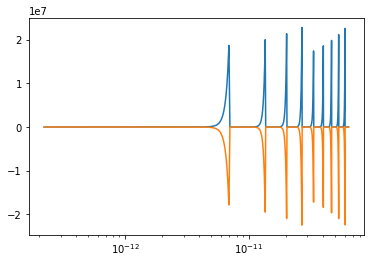

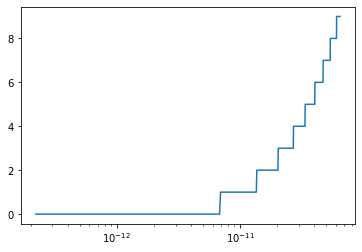

In [220]:
plt.plot(data[0],data[1])
plt.plot(data[0],data[2])
plt.xscale('log')
#plt.yscale('symlog')
plt.show()

plt.plot(data[0],data[4])
plt.xscale('log')
#plt.yscale('symlog')
plt.show()


In [214]:
data[1]

array([3.79462333e-01, 4.21933664e-01, 4.65511843e-01, 5.10623187e-01,
       5.57628888e-01, 6.06852402e-01, 6.58596281e-01, 7.13153110e-01,
       7.70812998e-01, 8.31868993e-01, 8.96621196e-01, 9.65380066e-01,
       1.03846919e+00, 1.11622776e+00, 1.19901279e+00, 1.28720128e+00,
       1.38119230e+00, 1.48140910e+00, 1.58830118e+00, 1.70234650e+00,
       1.82405375e+00, 1.95396468e+00, 2.09265661e+00, 2.24074503e+00,
       2.39888638e+00, 2.56778096e+00, 2.74817609e+00, 2.94086939e+00,
       3.14671232e+00, 3.36661395e+00, 3.60154495e+00, 3.85254187e+00,
       4.12071171e+00, 4.40723675e+00, 4.71337978e+00, 5.04048964e+00,
       5.39000708e+00, 5.76347117e+00, 6.16252596e+00, 6.58892773e+00,
       7.04455269e+00, 7.53140516e+00, 8.05162639e+00, 8.60750391e+00,
       9.20148155e+00, 9.83617015e+00, 1.05143590e+01, 1.12390280e+01,
       1.20133606e+01, 1.28407582e+01, 1.37248545e+01, 1.46695314e+01,
       1.56789364e+01, 1.67575005e+01, 1.79099577e+01, 1.91413653e+01,
      